<a href="https://colab.research.google.com/github/NaveenS-cool/AOD-analysis/blob/main/AOD_Singrauli_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!git clone https://github.com/NaveenS-cool/AOD-analysis.git

fatal: destination path 'AOD-analysis' already exists and is not an empty directory.


In [21]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Paths — change to your actual folder path
base = '/content/AOD-analysis/rasters/'
boundary = '/content/AOD-analysis/shapefile/Singrauli_Boundary.geojson'

def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(float), src.profile, src.bounds

annual,  profile, bounds = load_raster(base + 'Annual_AOD_2023.tif')
winter,  _, _ = load_raster(base + 'Winter_AOD_2022-23.tif')
summer,  _, _ = load_raster(base + 'Summer_AOD_2023.tif')
monsoon, _, _ = load_raster(base + 'Monsoon_AOD_2023.tif')
postmon, _, _ = load_raster(base + 'PostMonsoon_AOD_2023.tif')
no2,     _, _ = load_raster(base + 'NO2_2023.tif')
so2,     _, _ = load_raster(base + 'SO2_2023.tif')

# Load boundary
singrauli = gpd.read_file(boundary)

print('All files loaded ✅')
print(f'Raster shape: {annual.shape}')

All files loaded ✅
Raster shape: (103, 105)


In [23]:
# Check raw stats first
for name, arr in zip(['Annual','Winter','Summer','Monsoon','PostMonsoon','NO2','SO2'],
                     [annual, winter, summer, monsoon, postmon, no2,so2]):
    print(f'{name:12s} → Min: {np.nanmin(arr):.4f}  Max: {np.nanmax(arr):.4f}  Mean: {np.nanmean(arr):.4f}')

Annual       → Min: 77.7500  Max: 567.7059  Mean: 485.7701
Winter       → Min: 104.0000  Max: 435.5000  Mean: 337.5441
Summer       → Min: 70.0000  Max: 624.0000  Mean: 515.1304
Monsoon      → Min: 0.0000  Max: 1673.5000  Mean: 562.6285
PostMonsoon  → Min: 14.0000  Max: 836.0000  Mean: 593.2920
NO2          → Min: 0.0000  Max: 0.0005  Mean: 0.0001
SO2          → Min: 0.0001  Max: 0.0012  Mean: 0.0003


In [24]:
# Apply MODIS AOD scale factor
scale = 0.001

annual  = np.where((annual  <= 0) | (annual  > 2000), np.nan, annual  * scale)
winter  = np.where((winter  <= 0) | (winter  > 2000), np.nan, winter  * scale)
summer  = np.where((summer  <= 0) | (summer  > 2000), np.nan, summer  * scale)
monsoon = np.where((monsoon <= 0) | (monsoon > 2000), np.nan, monsoon * scale)
postmon = np.where((postmon <= 0) | (postmon > 2000), np.nan, postmon * scale)

# NO2 already in correct units — just mask nodata
no2 = np.where(no2 <= 0, np.nan, no2)
so2 = np.where(so2 <= 0, np.nan, so2)

# Check scaled stats
for name, arr in zip(['Annual','Winter','Summer','Monsoon','PostMonsoon','NO2','SO2'],
                     [annual, winter, summer, monsoon, postmon, no2,so2]):
    print(f'{name:12s} → Min: {np.nanmin(arr):.4f}  Max: {np.nanmax(arr):.4f}  Mean: {np.nanmean(arr):.4f}')

Annual       → Min: 0.0777  Max: 0.5677  Mean: 0.4858
Winter       → Min: 0.1040  Max: 0.4355  Mean: 0.3375
Summer       → Min: 0.0700  Max: 0.6240  Mean: 0.5151
Monsoon      → Min: 0.0140  Max: 1.6735  Mean: 0.5627
PostMonsoon  → Min: 0.0140  Max: 0.8360  Mean: 0.5933
NO2          → Min: 0.0000  Max: 0.0005  Mean: 0.0001
SO2          → Min: 0.0001  Max: 0.0012  Mean: 0.0003


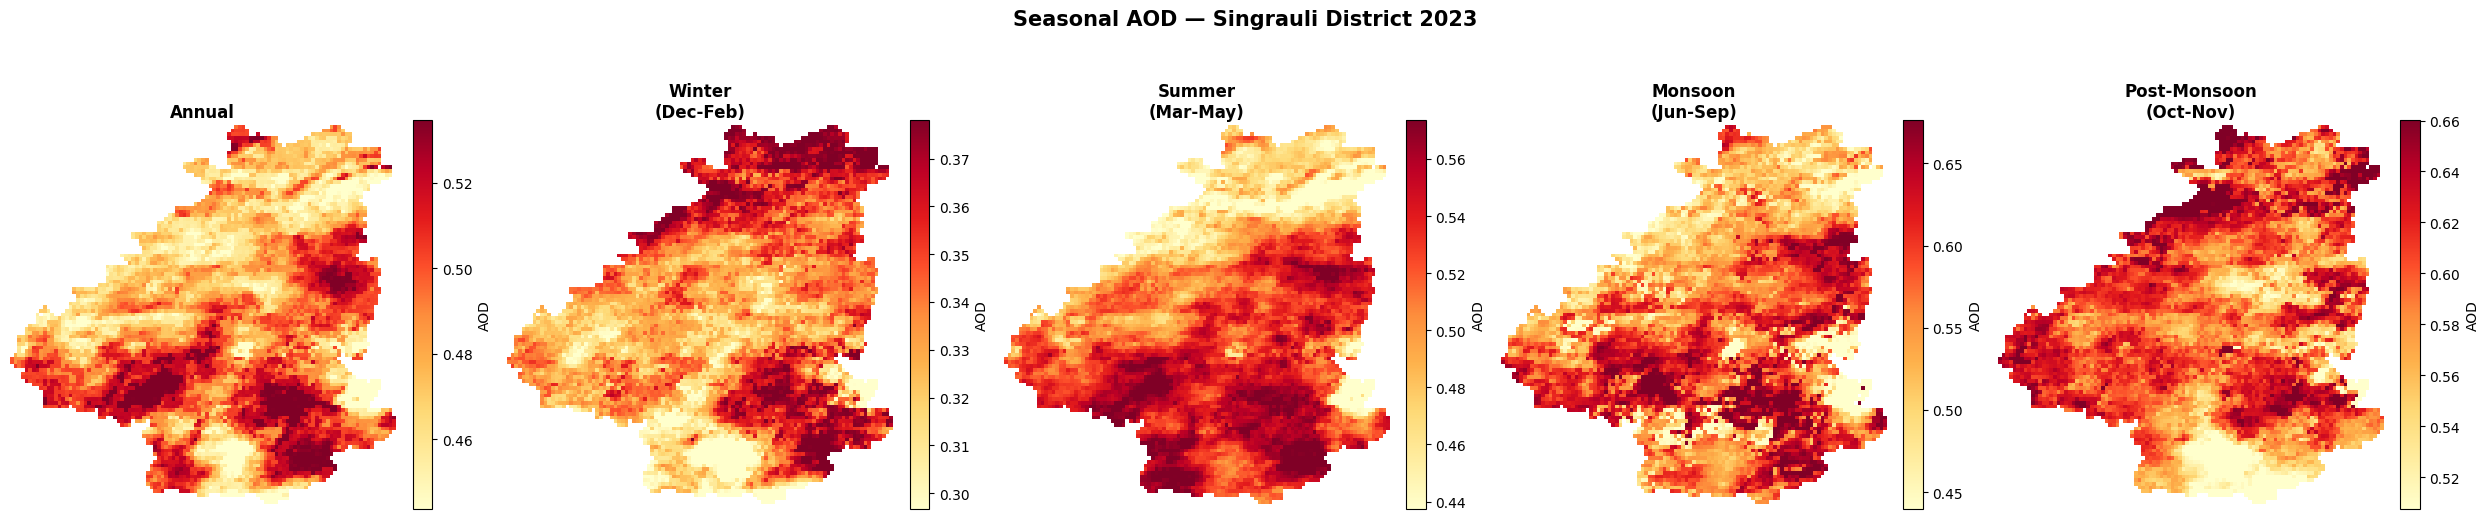

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

seasons = ['Annual', 'Winter\n(Dec-Feb)', 'Summer\n(Mar-May)',
           'Monsoon\n(Jun-Sep)', 'Post-Monsoon\n(Oct-Nov)']
arrays  = [annual, winter, summer, monsoon, postmon]

for ax, arr, name in zip(axes, arrays, seasons):
    vmin = np.nanpercentile(arr, 5)
    vmax = np.nanpercentile(arr, 95)
    im = ax.imshow(arr, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='AOD')

plt.suptitle('Seasonal AOD — Singrauli District 2023',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Singrauli_Seasonal_AOD.png', dpi=150, bbox_inches='tight')
plt.show()

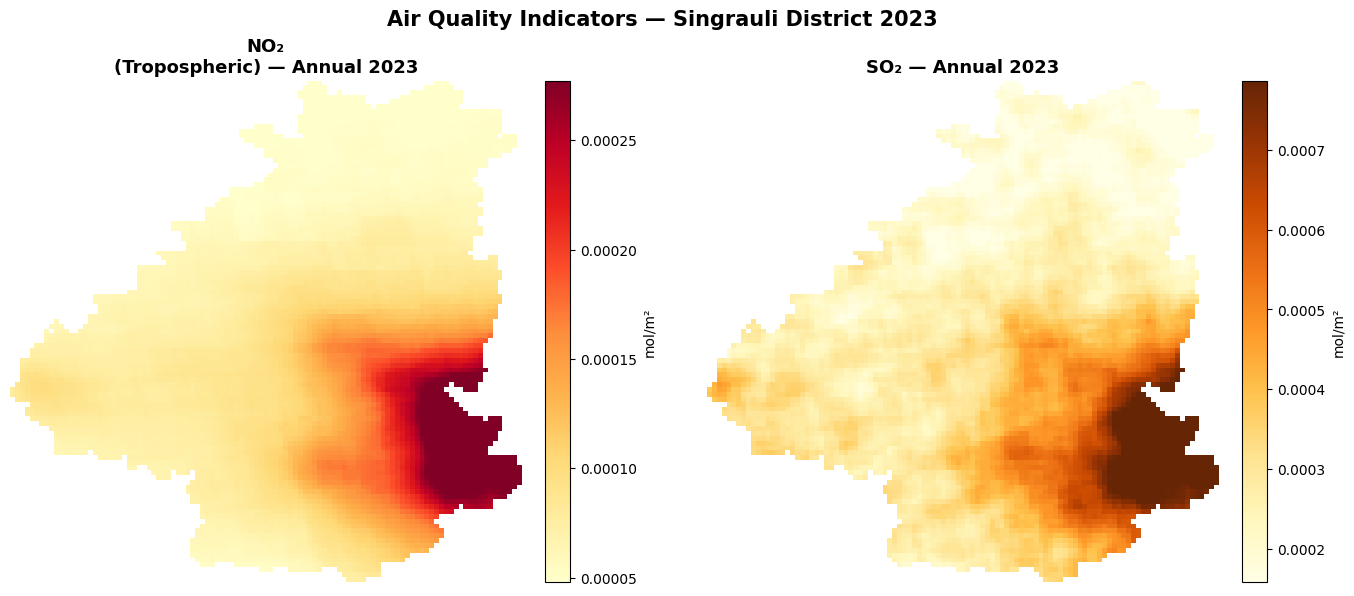

In [27]:
# Updated pollutant map — NO2 and SO2 only
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gases  = ['NO₂\n(Tropospheric)', 'SO₂']
arrays = [no2, so2]
cmaps  = ['YlOrRd', 'YlOrBr']

for ax, arr, name, cmap in zip(axes, arrays, gases, cmaps):
    vmin = np.nanpercentile(arr, 5)
    vmax = np.nanpercentile(arr, 95)
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f'{name} — Annual 2023', fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mol/m²')

plt.suptitle('Air Quality Indicators — Singrauli District 2023',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Singrauli_Pollutants.png', dpi=150, bbox_inches='tight')
plt.show()

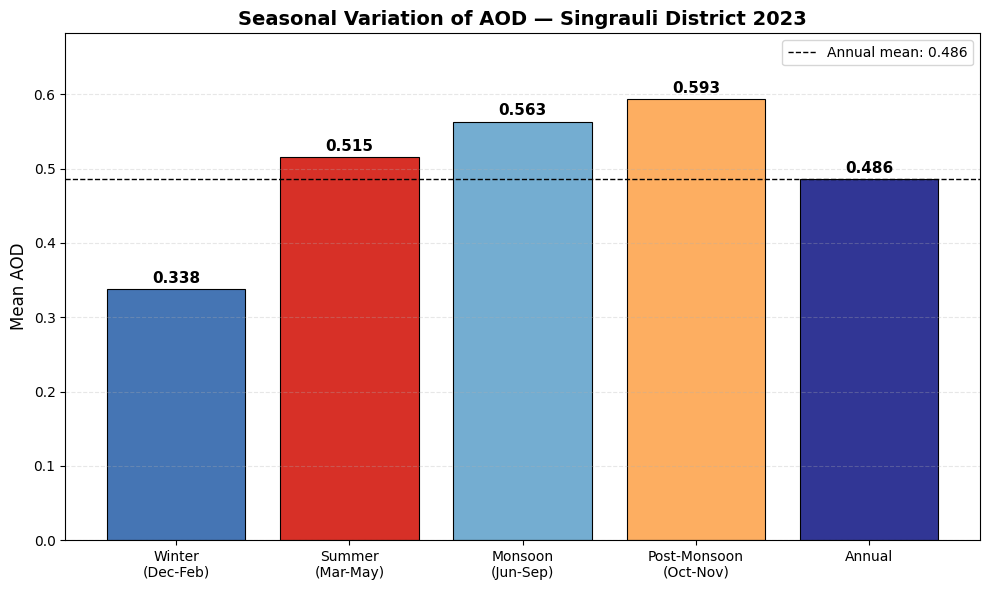

In [28]:
# Seasonal AOD bar chart
fig, ax = plt.subplots(figsize=(10, 6))

seasons = ['Winter\n(Dec-Feb)', 'Summer\n(Mar-May)',
           'Monsoon\n(Jun-Sep)', 'Post-Monsoon\n(Oct-Nov)', 'Annual']
means   = [np.nanmean(winter), np.nanmean(summer),
           np.nanmean(monsoon), np.nanmean(postmon), np.nanmean(annual)]
colors  = ['#4575b4', '#d73027', '#74add1', '#fdae61', '#313695']

bars = ax.bar(seasons, means, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Mean AOD', fontsize=12)
ax.set_title('Seasonal Variation of AOD — Singrauli District 2023',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(means) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=np.nanmean(annual), color='black',
           linestyle='--', linewidth=1, label=f'Annual mean: {np.nanmean(annual):.3f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('Singrauli_Seasonal_Bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Correlation Analysis — AOD vs NO2 vs SO2
import pandas as pd

# Flatten and combine
df = pd.DataFrame({
    'AOD' : annual.flatten(),
    'NO2' : no2.flatten(),
    'SO2' : so2.flatten()
}).dropna()

# Correlation matrix
corr = df.corr()
print('Correlation Matrix:')
print(corr)

Correlation Matrix:
          AOD       NO2       SO2
AOD  1.000000 -0.067430 -0.025801
NO2 -0.067430  1.000000  0.963469
SO2 -0.025801  0.963469  1.000000


NO2 vs SO2 → r = 0.963


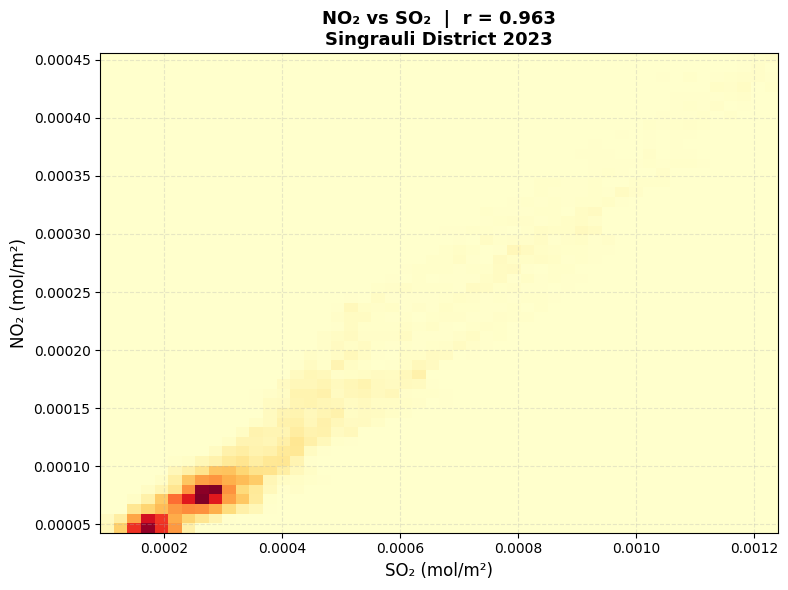

In [31]:
# NO2 vs SO2 correlation
df2 = pd.DataFrame({
    'NO2': no2.flatten(),
    'SO2': so2.flatten()
}).dropna()

r = df2.corr().loc['NO2', 'SO2']
print(f'NO2 vs SO2 → r = {r:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist2d(df2['SO2'], df2['NO2'], bins=50, cmap='YlOrRd')
ax.set_xlabel('SO₂ (mol/m²)', fontsize=12)
ax.set_ylabel('NO₂ (mol/m²)', fontsize=12)
ax.set_title(f'NO₂ vs SO₂  |  r = {r:.3f}\nSingrauli District 2023',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Singrauli_NO2_SO2_Corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
from scipy.ndimage import uniform_filter

# Smooth before classifying
def smooth(arr, size=3):
    filled = np.where(np.isnan(arr), np.nanmean(arr), arr)
    smoothed = uniform_filter(filled, size=size)
    return np.where(np.isnan(arr), np.nan, smoothed)

winter_s  = smooth(winter)
summer_s  = smooth(summer)
monsoon_s = smooth(monsoon)
postmon_s = smooth(postmon)

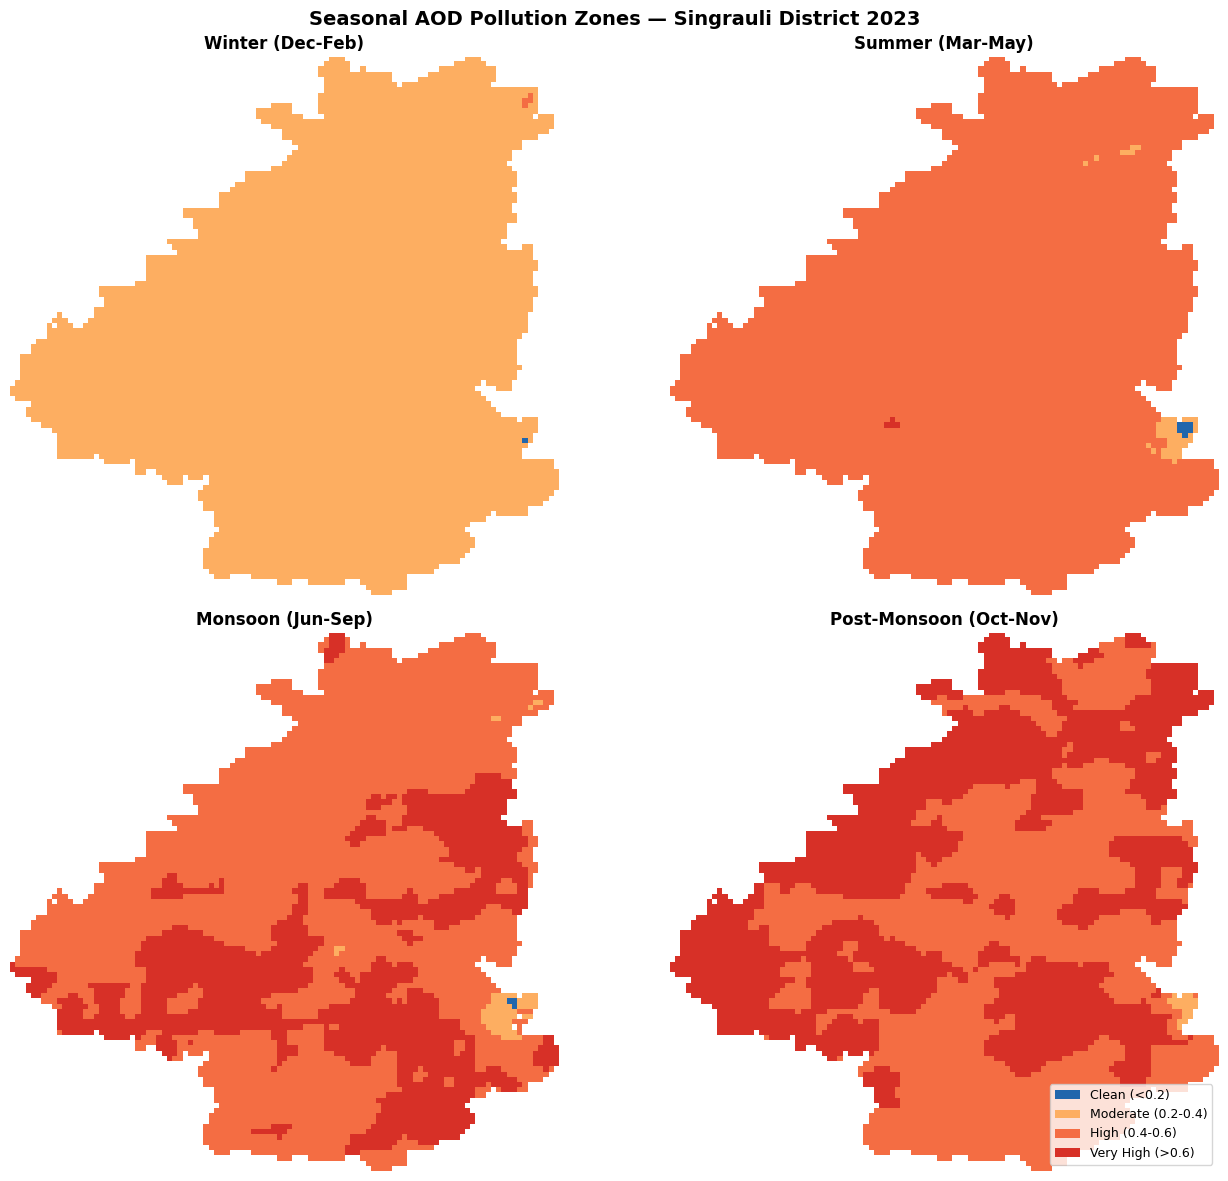

In [40]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# WHO/literature based AOD thresholds
# <0.2 = Clean, 0.2-0.4 = Moderate, 0.4-0.6 = High, >0.6 = Very High

def classify_aod(arr):
    zones_map = np.where(arr < 0.2, 1,
                np.where(arr < 0.4, 2,
                np.where(arr < 0.6, 3, 4)))
    return np.where(np.isnan(arr), np.nan, zones_map)

seasons_data = {
    'Winter (Dec-Feb)'      : winter_s,
    'Summer (Mar-May)'      : summer_s,
    'Monsoon (Jun-Sep)'     : monsoon_s,
    'Post-Monsoon (Oct-Nov)': postmon_s
}

zones  = ['Clean (<0.2)', 'Moderate (0.2-0.4)',
          'High (0.4-0.6)', 'Very High (>0.6)']
colors = ['#2166ac', '#fdae61', '#f46d43', '#d73027']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, arr) in zip(axes.flatten(), seasons_data.items()):
    zones_map = classify_aod(arr)
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5], cmap.N)
    ax.imshow(zones_map, cmap=cmap, norm=norm)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axis('off')

legend_elements = [Patch(facecolor=c, label=l) for c,l in zip(colors, zones)]
axes[1][1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Seasonal AOD Pollution Zones — Singrauli District 2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Singrauli_Seasonal_Zones.png', dpi=150, bbox_inches='tight')
plt.show()